In [1]:
## importing modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Reading CSV file into dataframe
df_comp = pd.read_csv("CompanyList_cl.csv")

In [3]:
df_comp

,Company Name,Industry,Rating,Highly rated,Critically_rated,Founded Year,Global Count,India Count,Years old
0,TCS,IT Services & Consulting,3.8,"Job Security, Work Life Balance","Promotions / Appraisal, Salary & Benefits, Wor...",1968,100000,100000,56
1,Accenture,IT Services & Consulting,4.0,"Company Culture, Skill Development / Learning,...",Promotions / Appraisal,1989,100000,100000,35
2,Cognizant,IT Services & Consulting,3.9,Skill Development / Learning,Promotions / Appraisal,1994,100000,100000,30
3,Wipro,IT Services & Consulting,3.8,Job Security,"Promotions / Appraisal, Salary & Benefits",1945,100000,100000,79
4,Capgemini,IT Services & Consulting,3.8,"Job Security, Work Life Balance, Skill Develop...","Promotions / Appraisal, Salary & Benefits",1967,100000,100000,57
...,...,...,...,...,...,...,...,...,...
490,Microland,IT Services & Consulting,3.5,"Promotions / Appraisal, Salary & Benefits, Wor...","Promotions / Appraisal, Salary & Benefits, Wor...",1989,100000,100000,35
491,MetLife,Insurance,4.3,"Work Life Balance, Job Security, Company Culture","Promotions / Appraisal, Salary & Benefits, Wor...",2008,100000,100000,16
492,SS&C TECHNOLOGIES,IT Services & Consulting,3.5,"Promotions / Appraisal, Work Life Balance, Wor...","Promotions / Appraisal, Work Life Balance, Wor...",2008,100000,100000,16
493,Spark Minda,Auto Components,3.9,Promotions / Appraisal,Promotions / Appraisal,1958,100000,100000,66


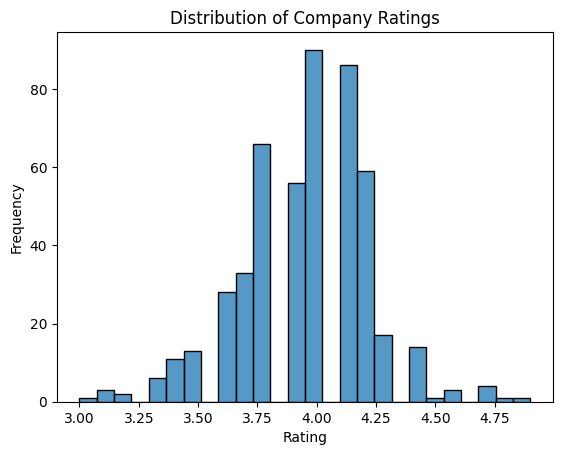

In [17]:
# plotting histogram for rating column
sns.histplot(df_comp['Rating'])
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Company Ratings')
plt.show()

HISTOGRAM is Univariate analysis,since it's focusing on single variable that is "Rating"

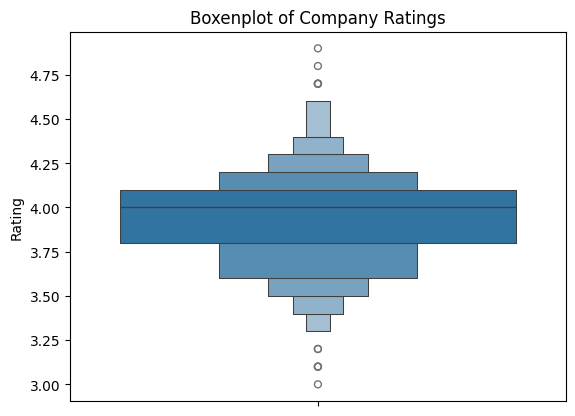

In [9]:
# plotting boxenplot for rating column
sns.boxenplot(df_comp['Rating'])
plt.title('Boxenplot of Company Ratings')
plt.show()

Boxenplot is Univariate analysis,since it's focusing on single variable that is "Rating"

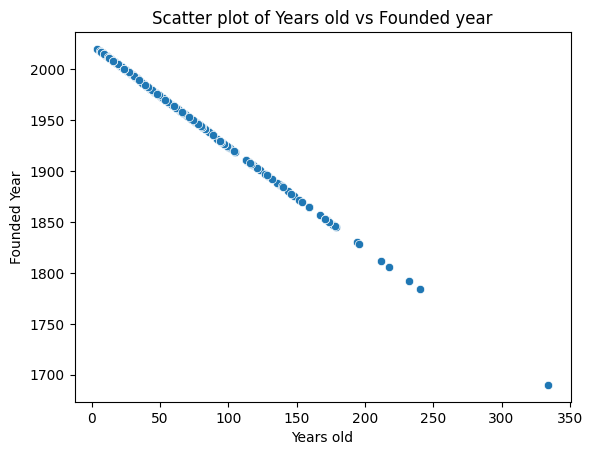

In [19]:
# Scatter plot of Years old vs Founded year
sns.scatterplot(x='Years old',y = 'Founded Year',data=df_comp)
plt.xlabel('Years old')
plt.ylabel('Founded Year')
plt.title('Scatter plot of Years old vs Founded year')
plt.show()

Above plot is Scatterplot, an example for Bivariate Analysis because it's focusing on 2 variables i.e, Founded year & Years old

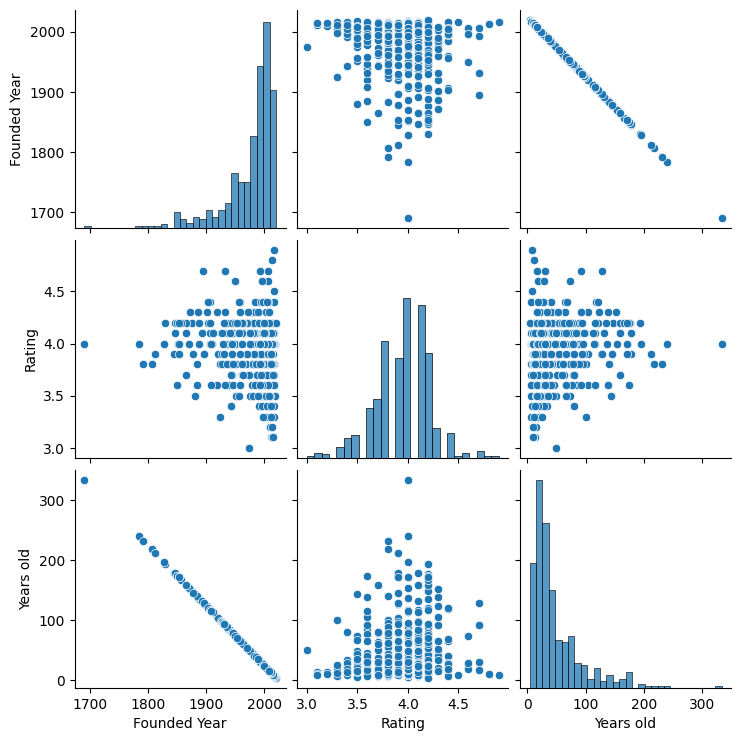

In [11]:
#pair plot of the specified columns
sns.pairplot(data=df_comp,vars=['Founded Year','Rating','Years old'])
plt.show()

Pairplot is also an example of bivariate analysis because it shows relation b/w 2 variables in each scatterplot

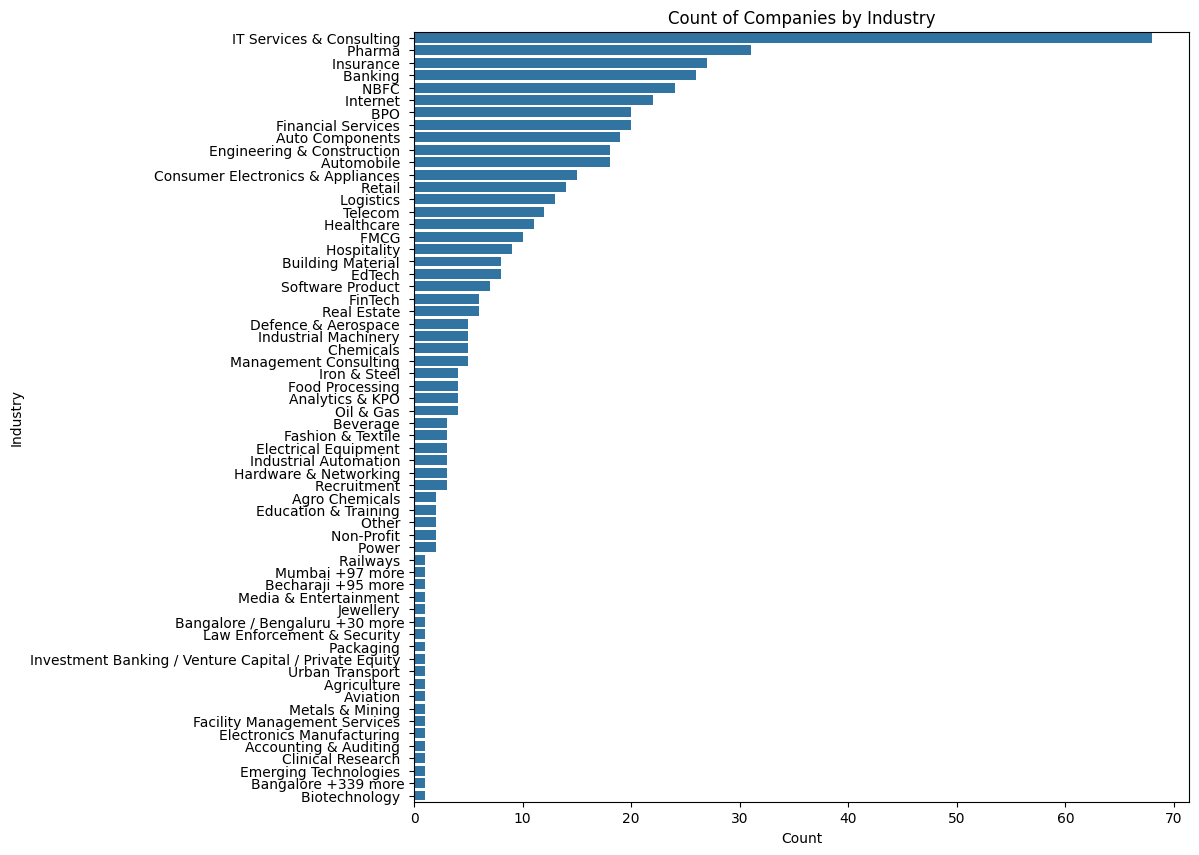

In [67]:
#Count of Companies by Industry
plt.figure(figsize=(10,10))
industry_counts = df_comp['Industry'].value_counts()
#print(industry_counts)
sns.barplot(x=industry_counts.values, y=industry_counts.index)
plt.title('Count of Companies by Industry')
plt.xlabel('Count')
plt.ylabel('Industry')
plt.show()

Bar plot is also bivariate analysis - 2 variables are Count & Industry

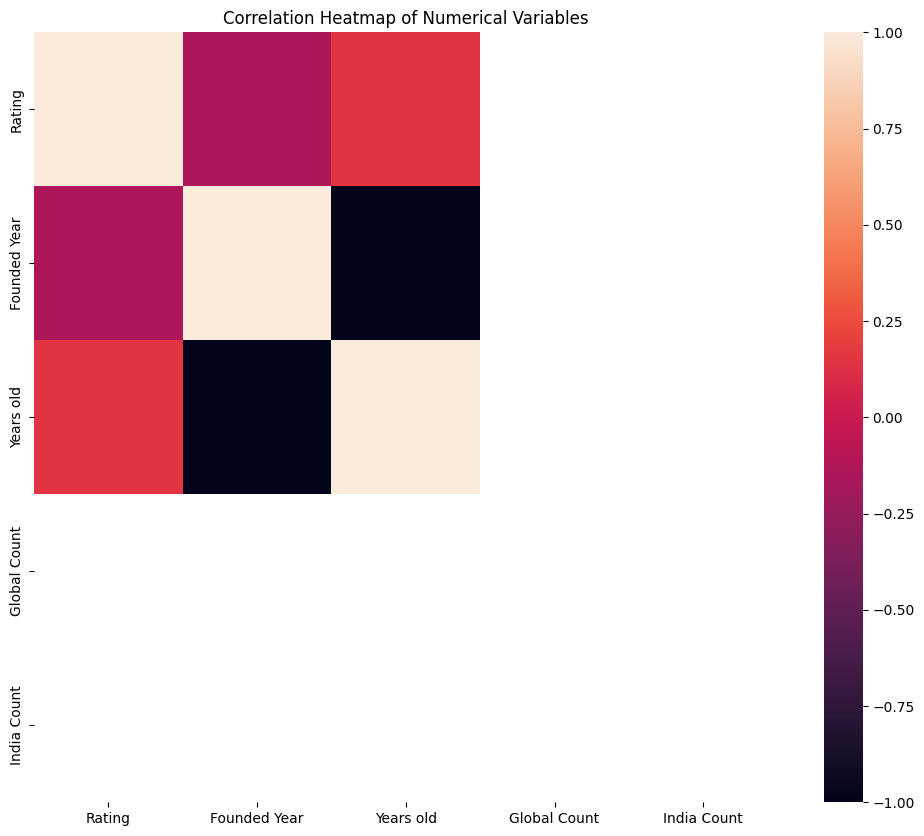

In [68]:
# Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df_comp[['Rating','Founded Year','Years old','Global Count','India Count']].corr()
sns.heatmap(correlation_matrix)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

heatmap is an example of bivariate analysis, it shows relation between variables & their correlataion.

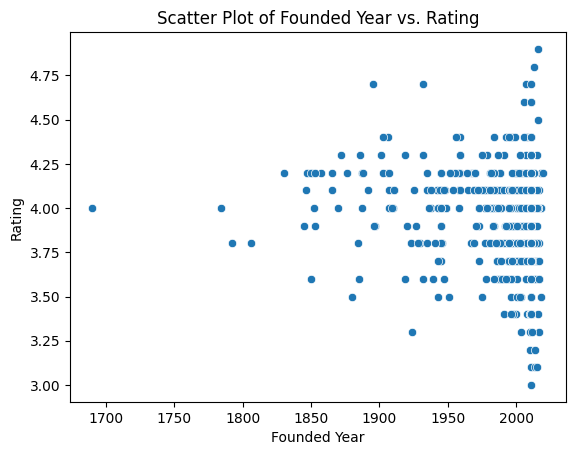

In [69]:
#scatterplot of Founded Year vs Rating
sns.scatterplot(x='Founded Year', y='Rating', data=df_comp)
plt.title('Scatter Plot of Founded Year vs Rating')
plt.xlabel('Founded Year')
plt.ylabel('Rating')
plt.show()


In [71]:
# define the Rated_count function
def Rated_count(column):
    li = column.apply(lambda x: x.split(','))
    count = {}
    for i in li:
        for j in i:
            j = j.strip()
            if j in count:
                count[j]+=1
            else:
                count[j]=1
    return count

# get the counts for 'Highly rated' & 'Critically_rated'
critical = Rated_count(df_comp['Critically_rated'])
high = Rated_count(df_comp['Highly rated'])

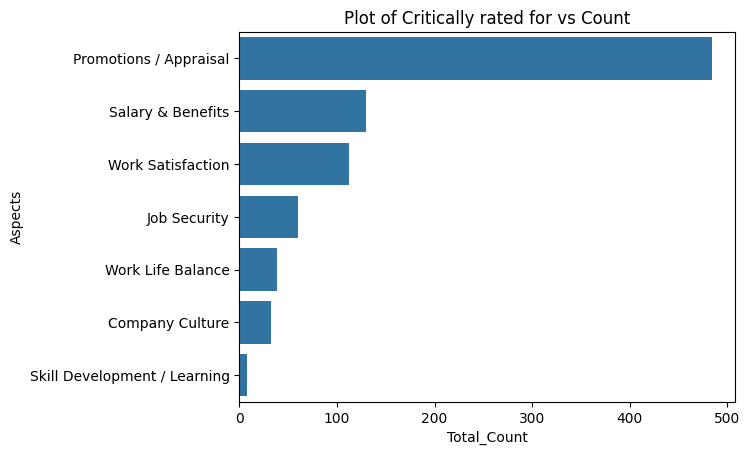

In [72]:
# barplot of Critically rated for vs Count
df_critical = pd.DataFrame(list(critical.items()),columns = ['Aspects','Total Count'])
sns.barplot(x='Total Count',y='Aspects', data=df_critical,orient='h')
plt.title('Plot of Critically rated for vs Count')
plt.xlabel('Total_Count')
plt.ylabel('Aspects')
plt.show()

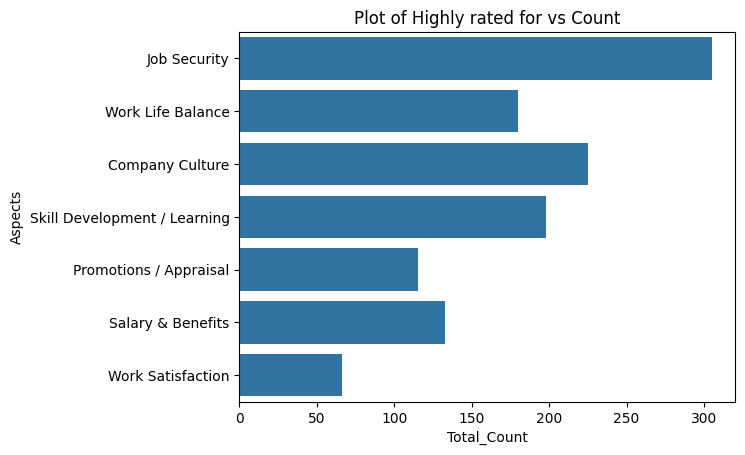

In [74]:
# barplot of Highly rated for vs Count
df_high = pd.DataFrame(list(high.items()),columns = ['Aspects','Total Count'])
sns.barplot(x='Total Count',y='Aspects', data=df_high,orient='h')
plt.title('Plot of Highly rated for vs Count')
plt.xlabel('Total_Count')
plt.ylabel('Aspects')
plt.show()

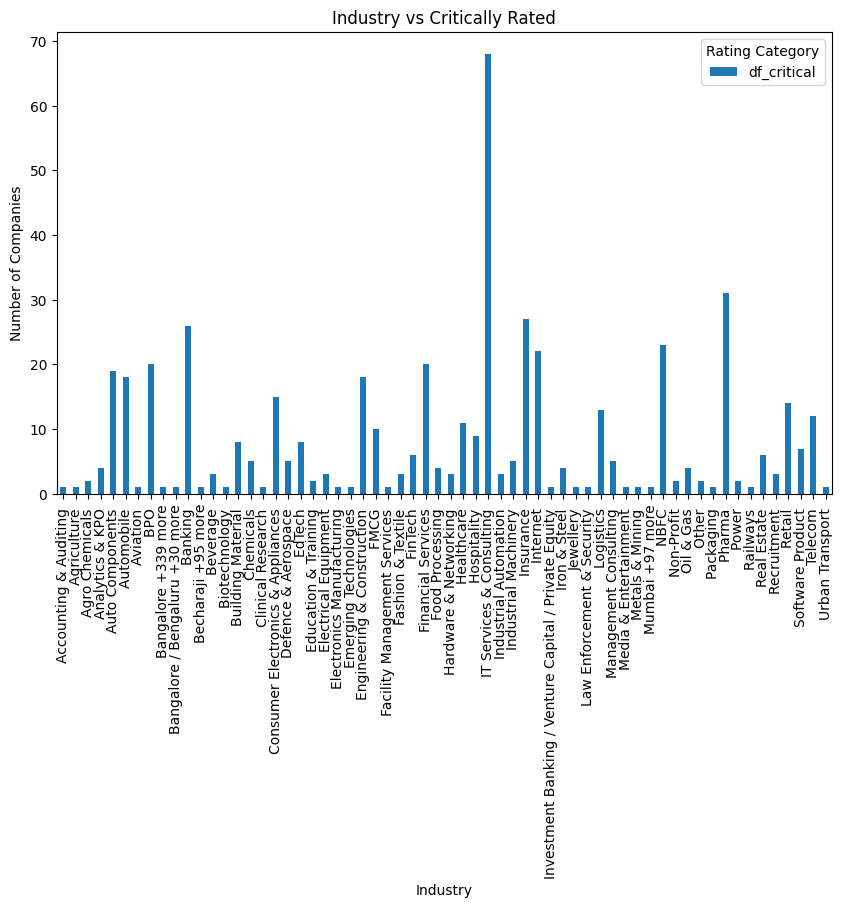

In [14]:

crosstab = pd.crosstab(df_comp['Industry'],'df_critical')

# Plot the crosstabulation as a bar plot
crosstab.plot(kind='bar', figsize=(10, 6))

plt.title('Industry vs Critically Rated')
plt.xlabel('Industry')
plt.ylabel('Number of Companies')
plt.xticks(rotation=90)
plt.legend(title='Rating Category')

# Show the plot
plt.show()
